# Data Visualization Tutorial: Matplotlib & Seaborn

This notebook provides a comprehensive guide to the two most popular visualization libraries in Python.

*   **Matplotlib**: The low-level foundation for plotting in Python.
*   **Seaborn**: A high-level interface built on top of Matplotlib for statistical graphics.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the California Housing dataset
data = pd.read_csv('/content/sample_data/california_housing_test.csv')

# For categorical examples, let's create a 'House_Age_Group' column
data['age_group'] = pd.cut(data['housing_median_age'], bins=[0, 10, 20, 30, 40, 60], labels=['New', 'Modern', 'Mid-Age', 'Old', 'Historic'])

display(data.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,age_group
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0,Mid-Age
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0,Historic
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0,Mid-Age
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0,Mid-Age
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0,Modern


## 1. Matplotlib Fundamentals
Matplotlib is highly customizable. We use `plt.subplots()` for the best control over layout.

## 1.1 Bar Charts and Pie Charts
Bar charts are ideal for comparing quantities across categories, while Pie charts show parts of a whole.

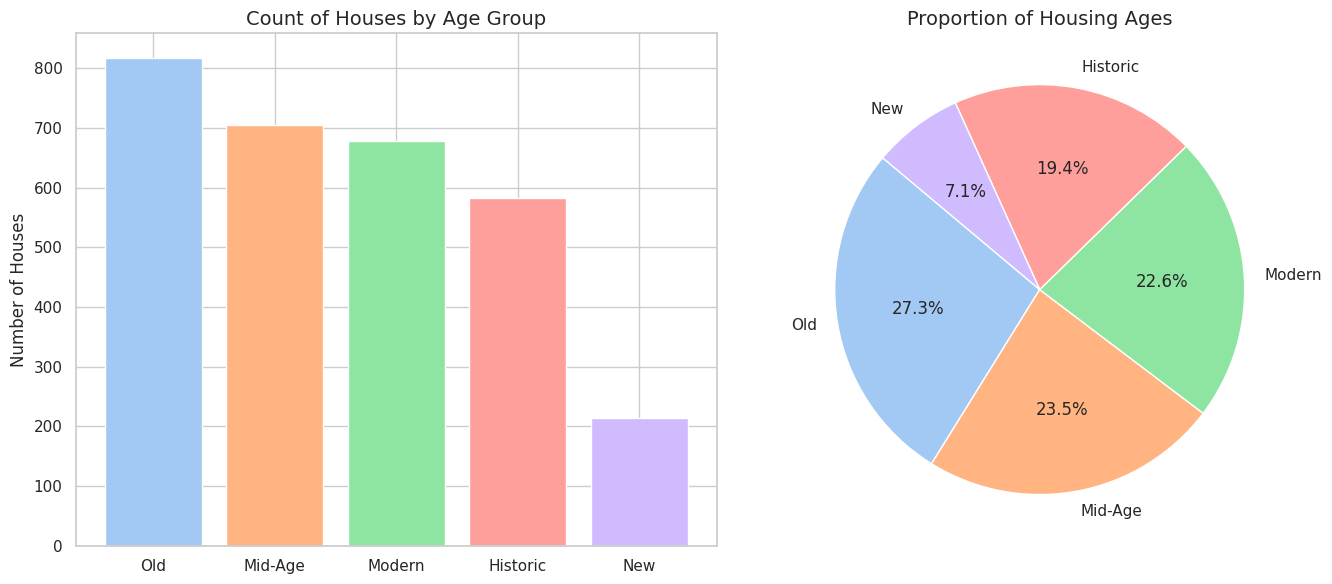

In [11]:
# Calculate data for the charts using House Age Groups
category_counts = data['age_group'].value_counts()
category_labels = category_counts.index
category_values = category_counts.values

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar Chart
ax1.bar(category_labels, category_values, color=sns.color_palette('pastel'))
ax1.set_title('Count of Houses by Age Group', fontsize=14)
ax1.set_ylabel('Number of Houses')

# 2. Pie Chart
ax2.pie(category_values, labels=category_labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
ax2.set_title('Proportion of Housing Ages', fontsize=14)

plt.tight_layout()
plt.show()

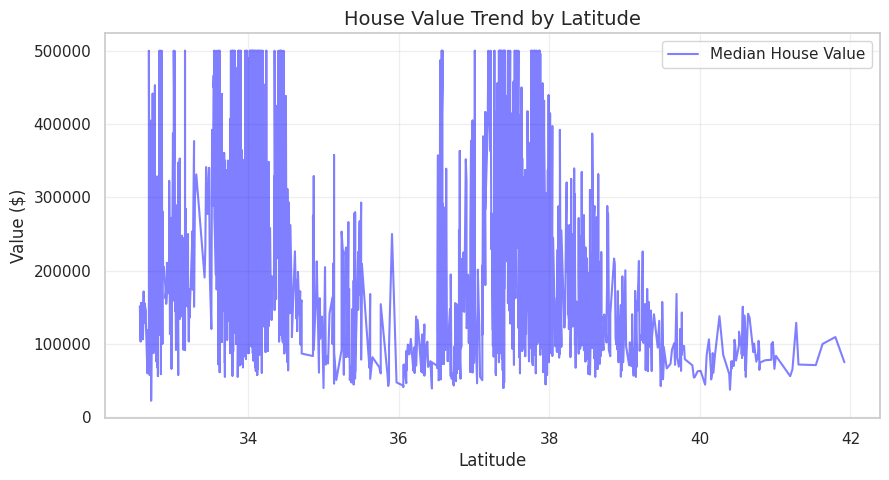

In [12]:
# Line Plot using sorted Latitude to see price trends geographically
sorted_data = data.sort_values('latitude')

plt.figure(figsize=(10, 5))
plt.plot(sorted_data['latitude'], sorted_data['median_house_value'], label='Median House Value', color='blue', alpha=0.5)

plt.title('House Value Trend by Latitude', fontsize=14)
plt.xlabel('Latitude')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. Seaborn for Statistical Data
Seaborn simplifies complex plots and integrates directly with Pandas DataFrames.

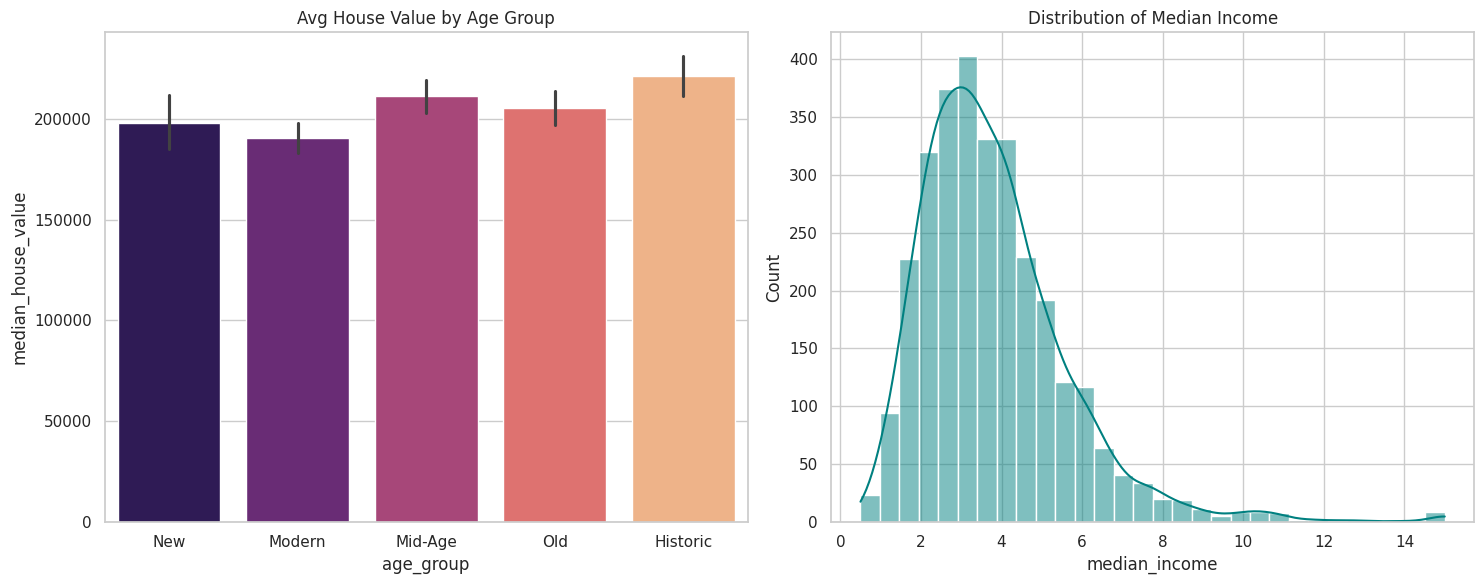

In [13]:
# Set Seaborn theme
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Bar Plot (Age Group vs Median House Value)
sns.barplot(data=data, x='age_group', y='median_house_value', ax=axes[0], palette='magma', hue='age_group', legend=False)
axes[0].set_title('Avg House Value by Age Group')

# Plot 2: Histogram (Median Income distribution)
sns.histplot(data['median_income'], bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribution of Median Income')

plt.tight_layout()
plt.show()

## 3. Relationship & Distribution Analysis
Useful for finding correlations between variables.

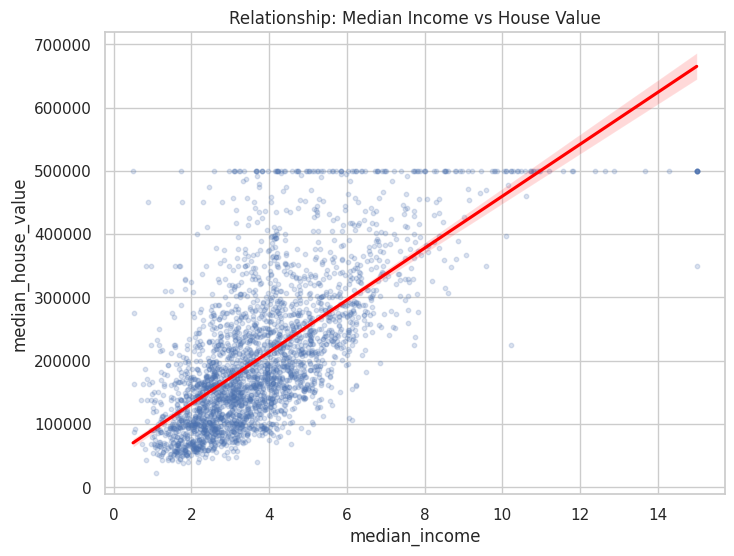

In [14]:
# Scatter Plot: Income vs House Value
plt.figure(figsize=(8, 6))
sns.regplot(data=data, x='median_income', y='median_house_value', scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
plt.title('Relationship: Median Income vs House Value')
plt.show()

## 4. Advanced Visualization: Heatmap
Perfect for correlation matrices.

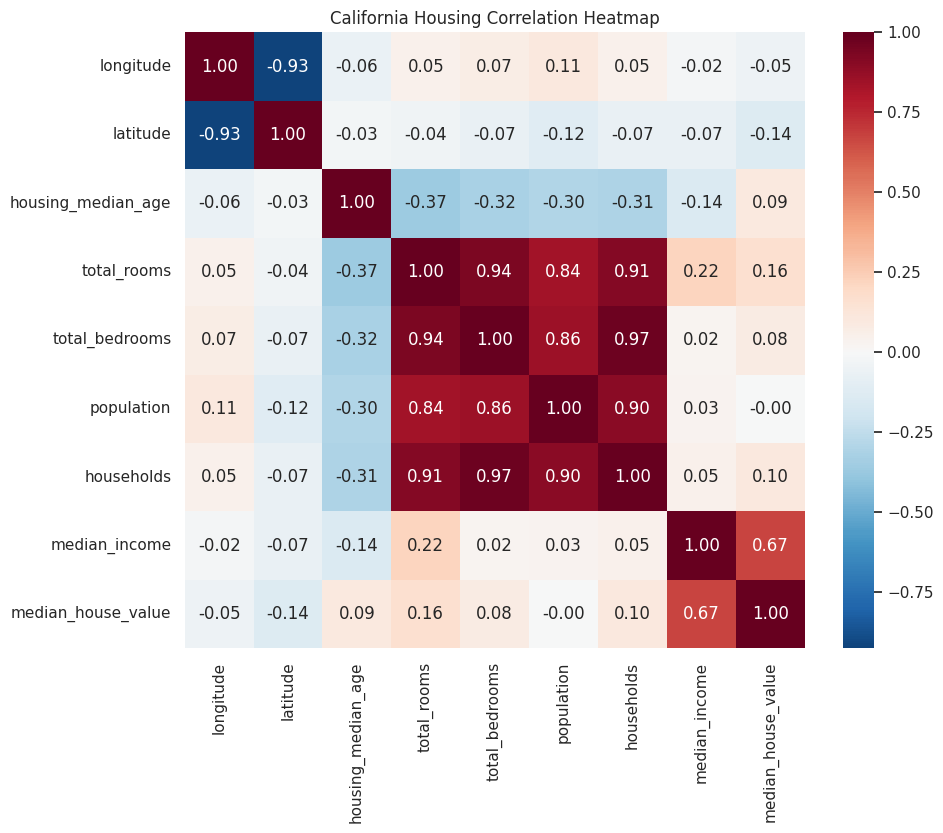

In [15]:
plt.figure(figsize=(10, 8))
# Correlation for the housing features
corr = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f', center=0)
plt.title('California Housing Correlation Heatmap')
plt.show()

## 5. Visualizing Distributions by Category
Boxen plots (or letter-value plots) provide more information about the shape of the distribution, especially in the tails.

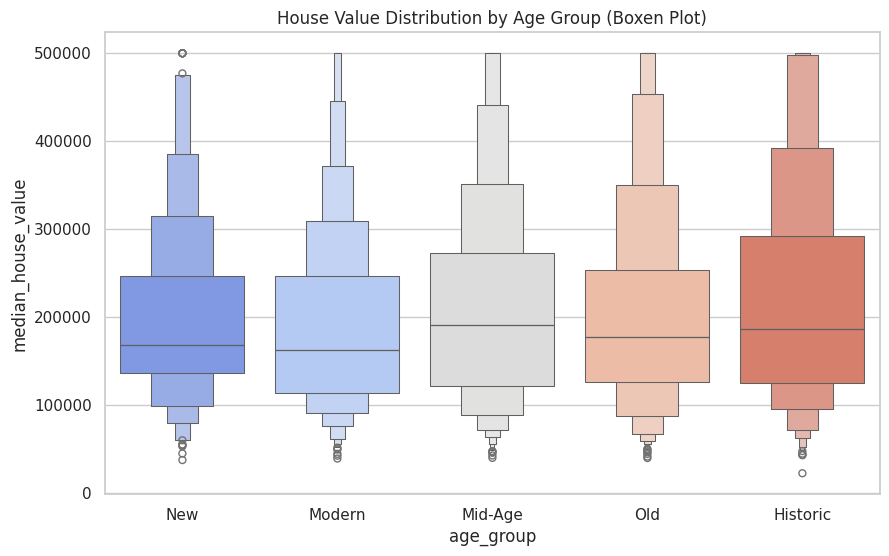

In [16]:
plt.figure(figsize=(10, 6))
sns.boxenplot(data=data, x='age_group', y='median_house_value', palette='coolwarm', hue='age_group', legend=False)
plt.title('House Value Distribution by Age Group (Boxen Plot)')
plt.show()

## 6. Faceting with FacetGrid
Faceting allows you to visualize the same relationship across different subsets of your data.

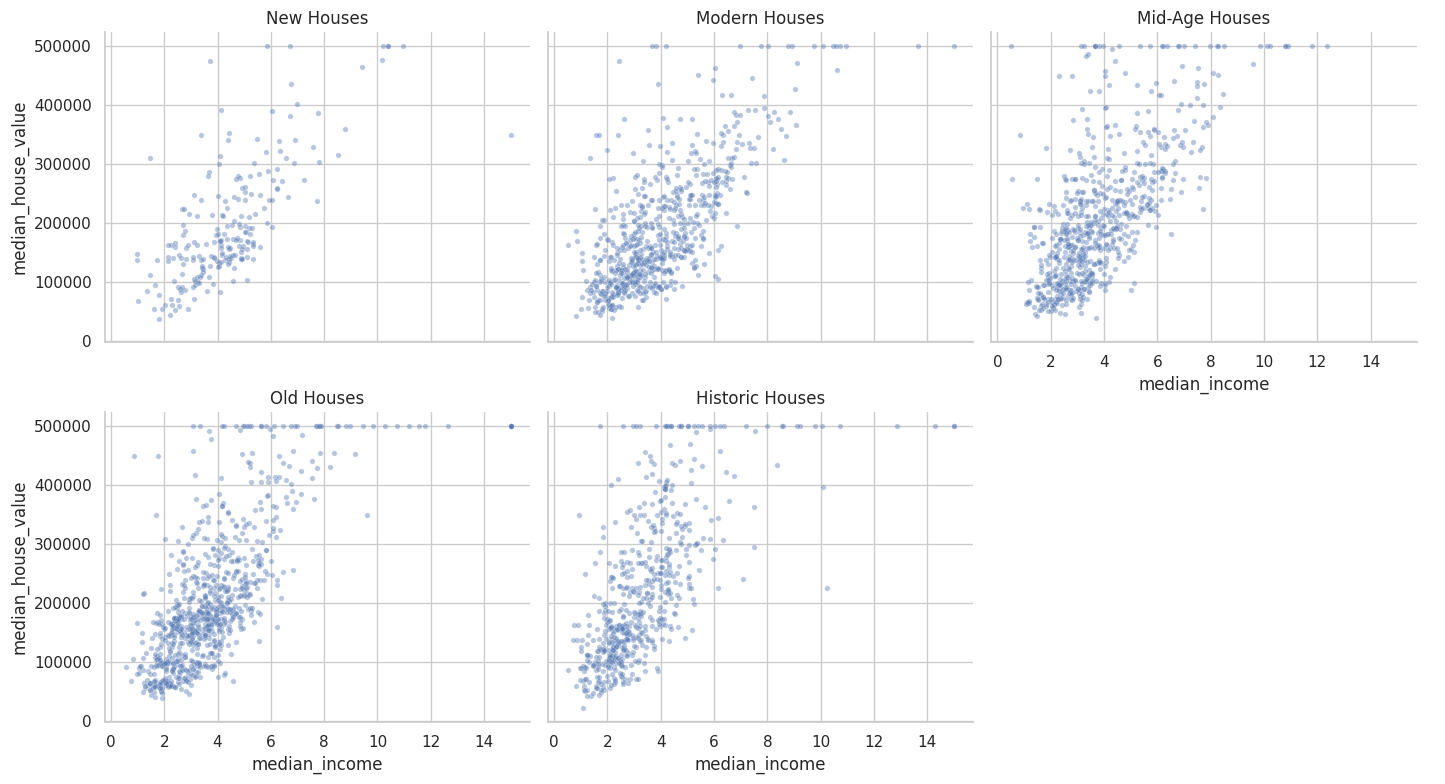

In [17]:
# We'll use a subset of groups for clearer faceting
g = sns.FacetGrid(data, col="age_group", col_wrap=3, height=4, aspect=1.2)
g.map(sns.scatterplot, "median_income", "median_house_value", alpha=0.4, s=15)
g.add_legend()
g.set_titles("{col_name} Houses")
plt.show()

## 7. Pair Plots
Pair plots are the quickest way to explore every numerical relationship in a dataframe.

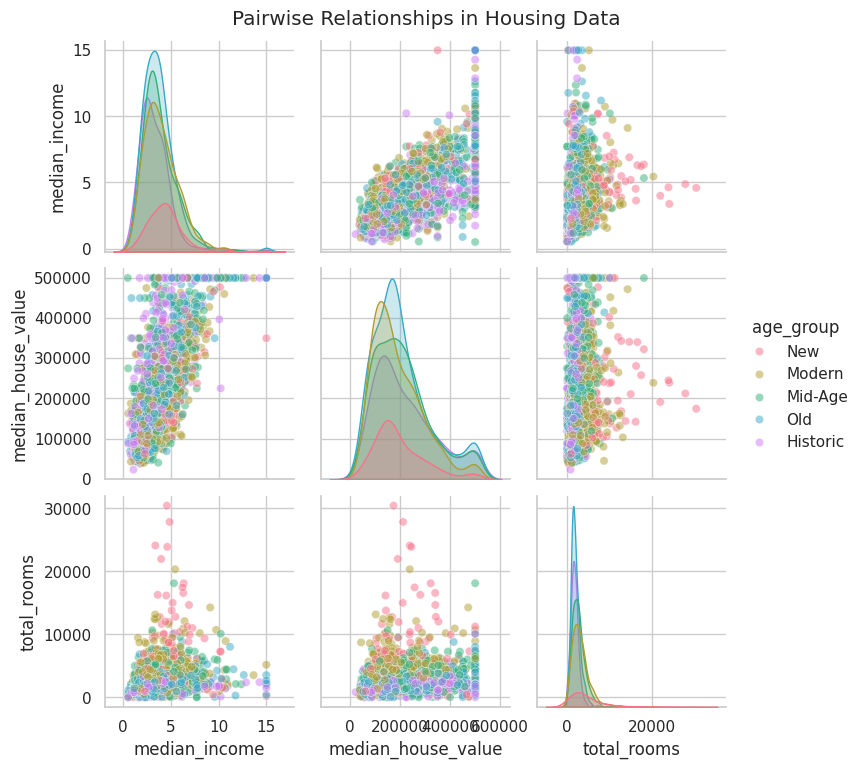

In [19]:
# Selecting a few key features for the pair plot to keep it readable
features = ['median_income', 'median_house_value', 'total_rooms', 'age_group']
sns.pairplot(data[features], hue='age_group', diag_kind='kde', palette='husl', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships in Housing Data', y=1.02)
plt.show()